In [12]:
## Task 1  —  Vectorize It

import numpy as np
prices = [10,20,20,40,50,60,50,70,80,90,10,20,20,40,50,60,50,70,80,90]

# Loop-based version: Apply 8% tax
taxed_prices_loop = []

for p in prices:
    taxed = p*1.8
    taxed_prices_loop.append(taxed)

print("Looped based taxed prices:")
print(taxed_prices_loop)

# NumPy vectorized version
price_array = np.array(prices)
taxed_prices_numpy = price_array*1.8

print("Numpy based taxed prices:")
print(taxed_prices_numpy)

# Boolean masking
taxed_prices = taxed_prices_numpy
above_50 = taxed_prices[taxed_prices>50]

print("\nTaxed prices above 50:")
print(above_50)

# 2D NumPy array
data = np.array([
    [10, 20, 30, 40],
    [50, 60, 70, 80],
    [90, 100, 110, 120]
])

# Row sums
row_sums = data.sum(axis=1)
# column sums
column_sums = data.sum(axis=1)

print("Sum of rows:")
print(row_sums)
print("Sum of columns:")
print(column_sums)

Looped based taxed prices:
[18.0, 36.0, 36.0, 72.0, 90.0, 108.0, 90.0, 126.0, 144.0, 162.0, 18.0, 36.0, 36.0, 72.0, 90.0, 108.0, 90.0, 126.0, 144.0, 162.0]
Numpy based taxed prices:
[ 18.  36.  36.  72.  90. 108.  90. 126. 144. 162.  18.  36.  36.  72.
  90. 108.  90. 126. 144. 162.]

Taxed prices above 50:
[ 72.  90. 108.  90. 126. 144. 162.  72.  90. 108.  90. 126. 144. 162.]
Sum of rows:
[100 260 420]
Sum of columns:
[100 260 420]


In [14]:
## Task 2  —  Load & Explore
import pandas as pd

# 1. Read CSV
df = pd.read_csv("employees.csv")

print("Employee Data:")
print(df)

# Display information about the DataFrame
print("\n--- DataFrame Info ---")
df.info()

# Display statistical summary
print("\n--- DataFrame Describe ---")
print(df.describe())


# 2. Filter IT department using boolean indexing
it_employees = df[df["department"] == "IT"]

print("\n--- IT Employees (Boolean Indexing) ---")
print(it_employees)


# Filter IT department using query()
it_employees_query = df.query("department == 'IT'")

print("\n--- IT Employees (query) ---")
print(it_employees_query)


# 3. Group by department and calculate:

department_summary = df.groupby("department").agg(
    average_salary=("salary", "mean"),
    headcount=("name", "count")
)

print("\n--- Department Summary ---")
print(department_summary)


# 4. Sort by average salary in descending order

sorted_summary = department_summary.sort_values(
    "average_salary",
    ascending=False
)

print("\n--- Sorted Department Summary ---")
print(sorted_summary)

Employee Data:
      name department  salary  years_experience
0    Rahul         IT   70000                 3
1    Priya         HR   50000                 2
2    Arjun         IT   85000                 5
3    Sneha    Finance   65000                 4
4   Vikram         HR   55000                 3
5   Ananya         IT   90000                 6
6    Rohit    Finance   72000                 5
7    Kavya      Sales   60000                 2
8    Kiran      Sales   68000                 4
9    Meera         IT   78000                 4
10  Suresh         HR   58000                 3
11   Divya    Finance   75000                 6
12   Akhil      Sales   62000                 3
13    Neha         IT   95000                 7
14   Varun    Finance   80000                 6

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 

In [15]:
## Task 3  —  Join the Data
import pandas as pd
import numpy as np


# --------------------------------------------------
# 1. Read employees data from Task 2 CSV
# --------------------------------------------------

employees = pd.read_csv("employees.csv")

print("--- Original Employees Data ---")
print(employees)


# --------------------------------------------------
# Create departments DataFrame
# --------------------------------------------------

departments = pd.DataFrame({
    "department": [
        "IT",
        "HR",
        "Finance",
        "Sales"
    ],
    "department_budget": [
        500000,
        300000,
        400000,
        350000
    ]
})

print("\n--- Departments DataFrame ---")
print(departments)


# --------------------------------------------------
# 2. Inner Join
# --------------------------------------------------

inner_merged = pd.merge(
    employees,
    departments,
    on="department",
    how="inner"
)

print("\n--- Inner Join ---")
print(inner_merged)


# --------------------------------------------------
# Add an employee whose department doesn't exist
# in the departments table
# --------------------------------------------------

new_employee = pd.DataFrame({
    "name": ["Ramesh"],
    "department": ["Marketing"],
    "salary": [65000],
    "years_experience": [3]
})

employees_with_new = pd.concat(
    [employees, new_employee],
    ignore_index=True
)

print("\n--- Employees After Adding Marketing Employee ---")
print(employees_with_new)


# --------------------------------------------------
# Left Join
# --------------------------------------------------

left_merged = pd.merge(
    employees_with_new,
    departments,
    on="department",
    how="left"
)

print("\n--- Left Join ---")
print(left_merged)


# --------------------------------------------------
# 3. Introduce missing values
# --------------------------------------------------

employees_with_new.loc[2, "salary"] = np.nan
employees_with_new.loc[5, "years_experience"] = np.nan

print("\n--- Data With Missing Values ---")
print(employees_with_new)


# Detect missing values
print("\n--- Missing Values Count ---")
print(employees_with_new.isna().sum())


# --------------------------------------------------
# 4. Handle missing values
# --------------------------------------------------

# Salary is numerical, so we fill the missing salary
# with the average salary instead of removing the employee.
employees_with_new["salary"] = employees_with_new["salary"].fillna(
    employees_with_new["salary"].mean()
)

# Years of experience is also numerical, so we fill
# the missing value with the average experience.
employees_with_new["years_experience"] = employees_with_new[
    "years_experience"
].fillna(
    employees_with_new["years_experience"].mean()
)

print("\n--- Data After Handling Missing Values ---")
print(employees_with_new)

--- Original Employees Data ---
      name department  salary  years_experience
0    Rahul         IT   70000                 3
1    Priya         HR   50000                 2
2    Arjun         IT   85000                 5
3    Sneha    Finance   65000                 4
4   Vikram         HR   55000                 3
5   Ananya         IT   90000                 6
6    Rohit    Finance   72000                 5
7    Kavya      Sales   60000                 2
8    Kiran      Sales   68000                 4
9    Meera         IT   78000                 4
10  Suresh         HR   58000                 3
11   Divya    Finance   75000                 6
12   Akhil      Sales   62000                 3
13    Neha         IT   95000                 7
14   Varun    Finance   80000                 6

--- Departments DataFrame ---
  department  department_budget
0         IT             500000
1         HR             300000
2    Finance             400000
3      Sales             350000

--- Inne

      name department  salary  years_experience
0    Rahul         IT   70000                 3
1    Priya         HR   50000                 2
2    Arjun         IT   85000                 5
3    Sneha    Finance   65000                 4
4   Vikram         HR   55000                 3
5   Ananya         IT   90000                 6
6    Rohit    Finance   72000                 5
7    Kavya      Sales   60000                 2
8    Kiran      Sales   68000                 4
9    Meera         IT   78000                 4
10  Suresh         HR   58000                 3
11   Divya    Finance   75000                 6
12   Akhil      Sales   62000                 3
13    Neha         IT   95000                 7
14   Varun    Finance   80000                 6


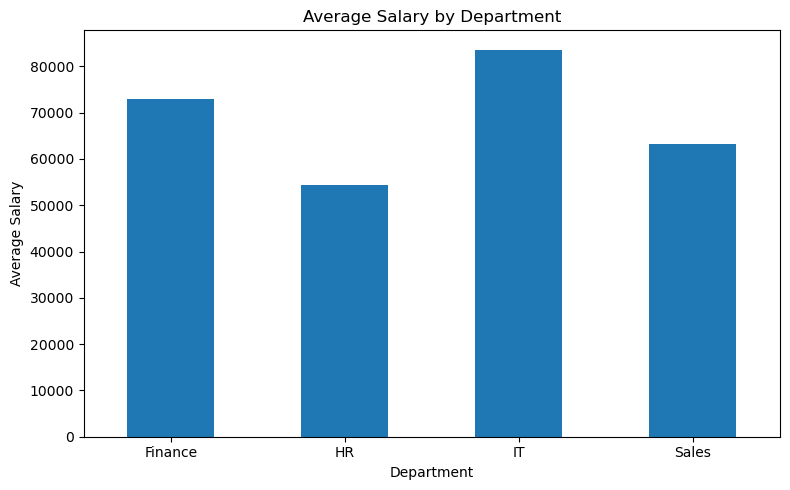

In [17]:
## Task 4  —  Tell a Story
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# --------------------------------------------------
# Load employees data
# --------------------------------------------------

employees = pd.read_csv("employees.csv")

print(employees)


# --------------------------------------------------
# 1. Bar Chart
# Average salary across departments
# --------------------------------------------------

average_salary = employees.groupby("department")["salary"].mean()

plt.figure(figsize=(8, 5))

average_salary.plot(kind="bar")

plt.title("Average Salary by Department")
plt.xlabel("Department")
plt.ylabel("Average Salary")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

# Question answered:
# "Which department has the highest or lowest average salary?"